<a href="https://colab.research.google.com/github/sahilabdushomat/PCD/blob/main/PCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

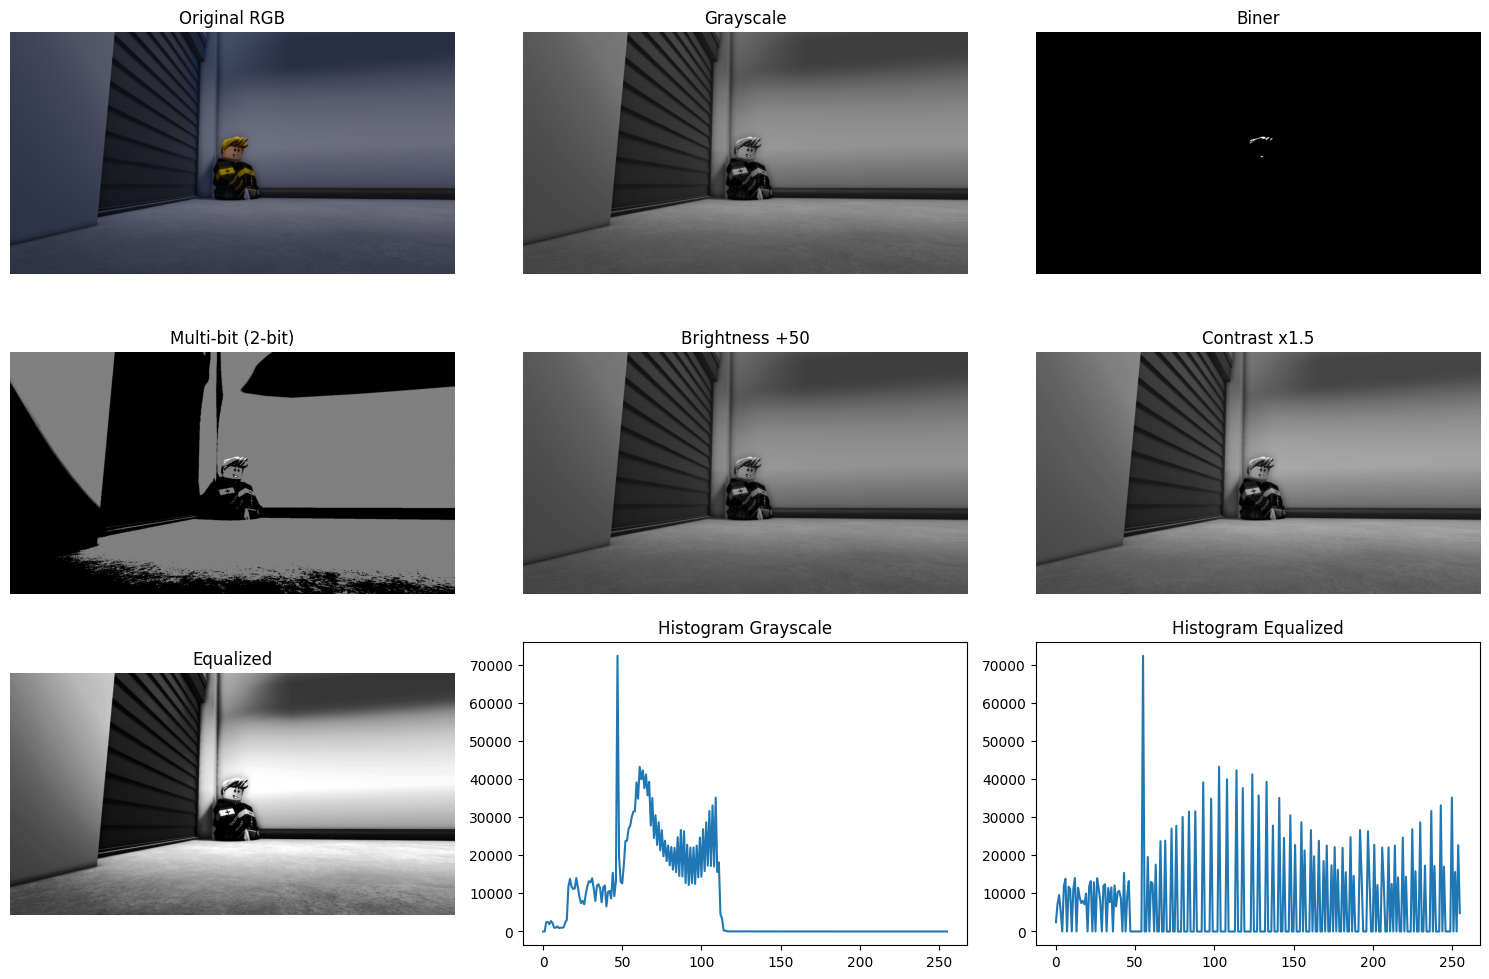

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img_path = '/content/p.png' # Ganti dengan nama file gambar Anda
img_rgb = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

# 1. Konversi RGB ke Grayscale
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# 2. Konversi Grayscale ke Biner (Thresholding)
# Menggunakan nilai ambang 127
_, img_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

# 3. Konversi Grayscale ke Multi-bit (Quantization)
# Mengurangi level keabuan (contoh: 2-bit atau 4 level warna)
bits = 2
levels = 2**bits
img_mbit = np.floor_divide(img_gray, 256//levels) * (256//levels)

# 4. Image dengan Brightness
# Menambah nilai pixel (konstan 50)
img_bright = cv2.convertScaleAbs(img_gray, alpha=1, beta=50)

# 5. Image dengan Contrast
# Mengalikan nilai pixel (alpha > 1 meningkatkan kontras)
img_contrast = cv2.convertScaleAbs(img_gray, alpha=1.5, beta=0)

# 6. Image Grayscale to Histogram
hist_gray = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

# 7. Image dengan Operasi Histogram Equalization
img_equalized = cv2.equalizeHist(img_gray)
hist_equalized = cv2.calcHist([img_equalized], [0], None, [256], [0, 256])

# --- Visualisasi Hasil ---
titles = ['Original RGB', 'Grayscale', 'Biner', 'Multi-bit (2-bit)',
          'Brightness +50', 'Contrast x1.5', 'Equalized']
images = [img_rgb, img_gray, img_binary, img_mbit,
          img_bright, img_contrast, img_equalized]

plt.figure(figsize=(15, 10))
for i in range(len(images)):
    plt.subplot(3, 3, i+1)
    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

# Plot Histogram
plt.subplot(3, 3, 8)
plt.plot(hist_gray)
plt.title('Histogram Grayscale')

plt.subplot(3, 3, 9)
plt.plot(hist_equalized)
plt.title('Histogram Equalized')

plt.tight_layout()
plt.show()